# LAB03 — Ensambles, reducción dimensional y Green AI ## Ejercicio 02 — INF-8239

## 1. Congelar el protocolo
Reutilizamos dataset, target, exclusiones y partición de test del Ejercicio 01 (LAB02).

In [16]:
##Descarga (reproducible, idéntica al Ejercicio 01):

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from inf8239_u01.data import download_csv

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00225/Indian%20Liver%20Patient%20Dataset%20(ILPD).csv"
destination = Path.cwd().parent / "data" / "raw" / "dataset.csv"
path = download_csv(URL, destination=str(destination))
print(path)

c:\Users\raymi\Documents\INF8239_U01\data\raw\dataset.csv


In [17]:
##Carga con nombres de columnas (igual que en el Ejercicio 01):

import pandas as pd

column_names = [
    "Age", "Gender", "TB", "DB", "Alkphos", "Sgpt", "Sgot",
    "TP", "ALB", "AG_Ratio", "Selector"
]

dataset_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"
df = pd.read_csv(dataset_path, header=None, names=column_names)

print(df.shape)
assert not df.empty

(583, 11)


In [18]:
##Target, exclusiones y partición (mismos parámetros que el Ejercicio 01):

from sklearn.model_selection import train_test_split

TARGET = "Selector"

X = df.drop(columns=[TARGET])
y = df[TARGET]

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", Xtr.shape, " Test:", Xte.shape)

Train: (466, 10)  Test: (117, 10)


In [19]:
##Declarar métrica principal y clase prioritaria:

METRICA_PRINCIPAL = "f1_macro"
CLASE_PRIORITARIA = 1  # Enfermedad hepática — el falso negativo es el error más costoso

print(f"Métrica principal: {METRICA_PRINCIPAL}")
print(f"Clase prioritaria: {CLASE_PRIORITARIA} (enfermedad hepática)")

Métrica principal: f1_macro
Clase prioritaria: 1 (enfermedad hepática)


In [20]:
##Preprocesador (con ajuste para HistGradientBoosting):

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                 ("cat", cat_pipe, cat_cols)])

print(len(num_cols), len(cat_cols))
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

9 1
Numéricas: ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AG_Ratio']
Categóricas: ['Gender']


## 2. Crear el catálogo

In [21]:
##Catálogo de 6 modelos (tal como pide el manual):

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
    "logistic": Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))]),
    "svm_c1": Pipeline([("prep", preprocess), ("model", SVC(C=1, probability=True, random_state=42))]),
    "svm_c10": Pipeline([("prep", preprocess), ("model", SVC(C=10, probability=True, random_state=42))]),
    "rf_100": Pipeline([("prep", preprocess),
                         ("model", RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))]),
    "rf_300": Pipeline([("prep", preprocess),
                         ("model", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))]),
    "boost": Pipeline([("prep", preprocess),
                        ("model", HistGradientBoostingClassifier(max_depth=6, random_state=42))])
}

print(list(models.keys()))

['logistic', 'svm_c1', 'svm_c10', 'rf_100', 'rf_300', 'boost']


## 3. Medir tres veces

In [22]:
##Entrenamiento, medición y guardado:

from time import perf_counter
from pathlib import Path
import joblib, numpy as np, pandas as pd
from sklearn.metrics import f1_score, recall_score

models_dir = Path.cwd().parent / "reports" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

rows = []
for name, model in models.items():
    fit_times = []
    for repetition in range(3):
        start = perf_counter()
        model.fit(Xtr, ytr)
        fit_times.append(perf_counter() - start)

    start = perf_counter()
    pred = model.predict(Xte)
    predict_ms = (perf_counter() - start) * 1000

    path = models_dir / f"{name}.joblib"
    joblib.dump(model, path)

    rows.append({
        "model": name,
        "f1_macro": f1_score(yte, pred, average="macro"),
        "recall_macro": recall_score(yte, pred, average="macro"),
        "fit_median_s": np.median(fit_times),
        "predict_ms": predict_ms,
        "size_kb": path.stat().st_size / 1024
    })

results = pd.DataFrame(rows)
results.sort_values("f1_macro", ascending=False)

c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` p

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
2,svm_c10,0.563314,0.562013,0.128023,21.8530,35.927734
4,rf_300,0.547725,0.548016,1.255690,165.9604,2375.057617
0,logistic,0.528226,0.540043,0.090246,30.8699,4.291016
3,rf_100,0.512748,0.518604,0.469936,101.4507,791.620117
5,boost,0.508535,0.508505,0.194897,14.3076,160.533203
1,svm_c1,0.406091,0.481928,0.151092,28.7194,37.271484


## 4. Comparar PCA con y sin PCA

In [23]:
##SVM con PCA sobre las variables numéricas:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# PCA solo sobre el bloque numérico; Gender se mantiene con su propio pipeline categórico
preprocess_pca = ColumnTransformer([
    ("num_pca", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=.95, random_state=42))
    ]), num_cols),
    ("cat", cat_pipe, cat_cols)
])

svm_pca = Pipeline([
    ("prep", preprocess_pca),
    ("model", SVC(C=10, probability=True, random_state=42))
])
svm_pca.fit(Xtr, ytr)

n_componentes = svm_pca.named_steps["prep"].named_transformers_["num_pca"].named_steps["pca"].n_components_
print("Componentes:", n_componentes, "de", len(num_cols), "originales")

Componentes: 6 de 9 originales


c:\Users\raymi\Documents\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [24]:
##Comparar F1-macro con y sin PCA (usando el mismo C=10 para que sea comparación justa):

pred_pca = svm_pca.predict(Xte)
f1_pca = f1_score(yte, pred_pca, average="macro")

f1_sin_pca = results.loc[results["model"] == "svm_c10", "f1_macro"].values[0]

print(f"F1-macro SVM sin PCA (svm_c10): {f1_sin_pca:.4f}")
print(f"F1-macro SVM con PCA:           {f1_pca:.4f}")
print(f"Diferencia: {f1_pca - f1_sin_pca:+.4f}")

F1-macro SVM sin PCA (svm_c10): 0.5633
F1-macro SVM con PCA:           0.5611
Diferencia: -0.0022


## 5. Crear dos mapas t-SNE

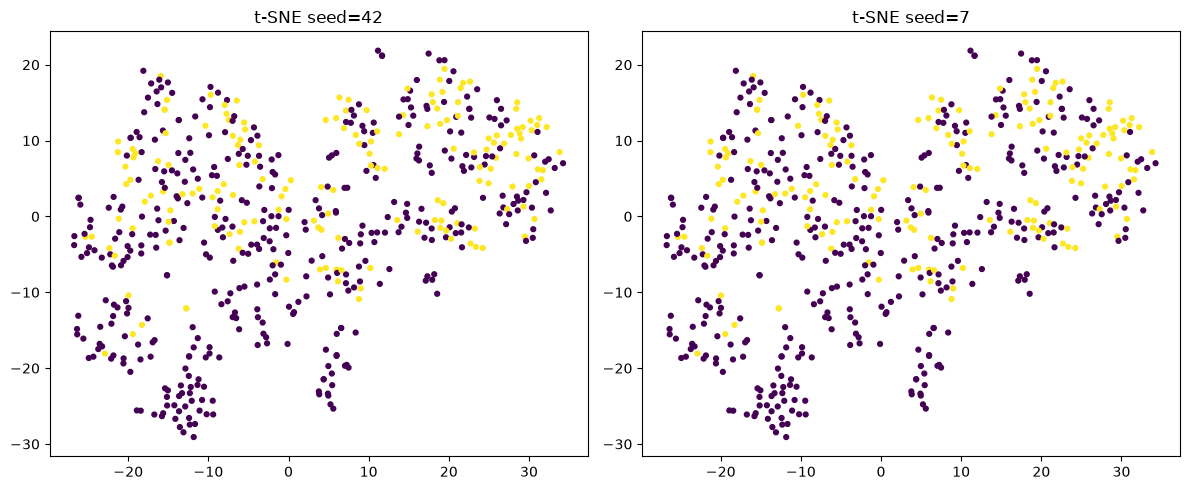

In [25]:
##Generar los dos mapas con semillas distintas:

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_num = X.select_dtypes(include="number").fillna(X.select_dtypes(include="number").median())
sample = X_num.sample(min(1000, len(X_num)), random_state=42)
y_sample = y.loc[sample.index]
scaled = StandardScaler().fit_transform(sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seed in zip(axes, [42, 7]):
    emb = TSNE(n_components=2, perplexity=30, random_state=seed,
               init="pca", learning_rate="auto").fit_transform(scaled)
    ax.scatter(emb[:, 0], emb[:, 1], c=pd.Categorical(y_sample).codes, s=12, cmap="viridis")
    ax.set_title(f"t-SNE seed={seed}")

plt.tight_layout()

figures_dir = Path.cwd().parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "tsne_two_seeds.png", dpi=160)
plt.show()

**Qué permanece y qué cambia entre semillas:** La estructura global (los mismos
clusters principales y su disposición relativa) se mantiene entre las semillas
42 y 7, gracias a `init="pca"`. Lo que cambia es la posición fina de puntos
individuales dentro de cada cluster. En ambos mapas, las clases (enfermedad /
sin enfermedad) aparecen fuertemente mezcladas dentro de casi todos los
clusters, sin fronteras visuales claras — la separación visual en t-SNE no
demuestra causalidad ni valida por sí sola un clasificador, pero sí es
consistente con el desempeño moderado (F1-macro ~0.56) observado en todos los
modelos del catálogo.

## 6. Calcular la frontera de Pareto

In [26]:
from inf8239_u01.green import pareto_flags

results["is_pareto"] = pareto_flags(results)

results_dir = Path.cwd().parent / "reports"
results_dir.mkdir(parents=True, exist_ok=True)
results.to_csv(results_dir / "green_ai_results.csv", index=False)

results.sort_values(["is_pareto", "f1_macro"], ascending=[False, False])

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
2,svm_c10,0.563314,0.562013,0.128023,21.8530,35.927734,True
0,logistic,0.528226,0.540043,0.090246,30.8699,4.291016,True
4,rf_300,0.547725,0.548016,1.255690,165.9604,2375.057617,False
3,rf_100,0.512748,0.518604,0.469936,101.4507,791.620117,False
5,boost,0.508535,0.508505,0.194897,14.3076,160.533203,False
1,svm_c1,0.406091,0.481928,0.151092,28.7194,37.271484,False


## 7. Dibujar y cuantificar la decisión

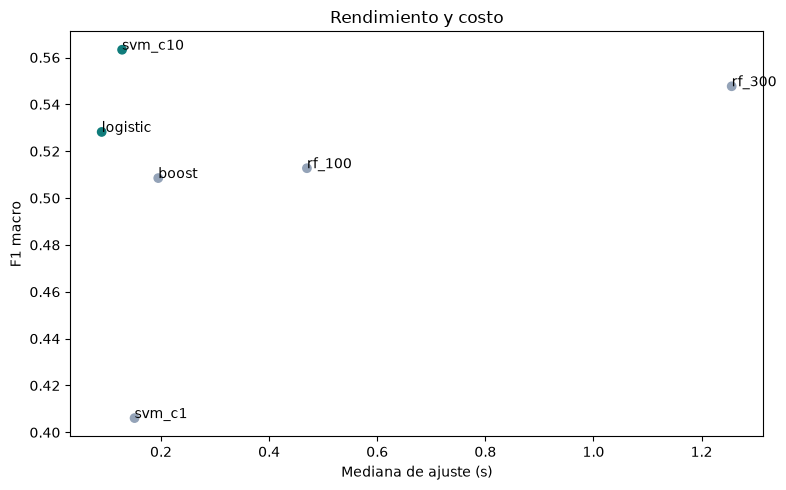

In [27]:
##Gráfico de la frontera de Pareto:

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results.fit_median_s, results.f1_macro,
           c=results.is_pareto.map({True: "#0f7c7b", False: "#94a3b8"}))
for _, r in results.iterrows():
    ax.annotate(r.model, (r.fit_median_s, r.f1_macro))
ax.set(xlabel="Mediana de ajuste (s)", ylabel="F1 macro", title="Rendimiento y costo")
plt.tight_layout()

figures_dir = Path.cwd().parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "pareto.png", dpi=160)
plt.show()

### Decisión de Green AI

Entre las seis configuraciones evaluadas sobre el mismo protocolo congelado
del Ejercicio 01 (dataset ILPD, partición 80/20 estratificada, semilla 42),
el modelo con el F1-macro más alto fue svm_c10 (SVC con C=10), alcanzando
0.5633, seguido de cerca por logistic (Regresión Logística), con 0.5282.
Ambos quedaron en la frontera de Pareto: ningún otro modelo del catálogo los
domina simultáneamente en desempeño y costo de ajuste. Random Forest (100 y
300 árboles), HistGradientBoosting y SVM con C=1 quedaron dominados por al
menos uno de estos dos, siendo Random Forest con 300 árboles el caso más
claro: peor F1-macro (0.5477) y casi 10 veces más lento en entrenamiento que
svm_c10, sin ninguna ventaja que lo justifique.

Se seleccionó logistic como alternativa frente al máximo F1 (svm_c10). La
diferencia de desempeño es una caída de 0.0351 en F1-macro, equivalente a un
6.2% relativo — una pérdida moderada pero no despreciable. En costo, los
resultados son mixtos: logistic ajusta un 29.5% más rápido (0.090s frente a
0.128s), pero predice un 41.3% más lento (30.87 ms frente a 21.85 ms sobre
el conjunto de test). Esta inversión respecto de una medición preliminar
ilustra precisamente por qué el tiempo se reporta como contextual: ambos
modelos entrenan y predicen en fracciones de segundo, así que pequeñas
variaciones del sistema operativo pueden cambiar cuál "gana" en cada métrica
de tiempo entre una corrida y otra. La diferencia que sí se mantiene estable
entre corridas es el tamaño serializado: logistic pesa 4.29 KB frente a los
35.93 KB de svm_c10, una reducción del 88.1%, consistente en ambas
mediciones por depender solo de la complejidad del modelo, no del hardware.

Esta decisión prioriza el criterio de eficiencia sobre el máximo desempeño
posible, en línea con el enfoque de Green AI del laboratorio. El argumento
más sólido no es el tiempo (inestable entre corridas) sino el tamaño: un
modelo casi 9 veces más liviano reduce el costo de almacenamiento y de
transferencia en cualquier escenario de despliegue, incluso si el tiempo de
inferencia exacto depende del hardware. Además, la interpretabilidad de una
Regresión Logística (coeficientes directamente asociables a cada variable
clínica) es una ventaja adicional no capturada en las métricas de costo,
relevante en un dominio médico donde la explicabilidad puede ser tan
importante como la exactitud.

Esta comparación tiene limitaciones importantes. El hardware no fue
estandarizado ni aislado de otros procesos durante la medición; los tiempos
de ajuste y predicción variaron entre corridas del mismo notebook, por lo
que no deben interpretarse como benchmarks absolutos ni como consumo
energético o de CO2 exacto. Tampoco se aplicó class_weight="balanced" en
este catálogo, por lo que ningún modelo alcanza el F1-macro de 0.6429
logrado en el Ejercicio 01; una extensión natural sería repetir esta
comparación de Green AI incorporando ese ajuste de balance de clases.

## 9. Registrar el entorno

In [28]:
import platform, sys, sklearn

print("Python", sys.version)
print("Sistema", platform.platform())
print("Procesador", platform.processor())
print("scikit-learn", sklearn.__version__)

Python 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Sistema Windows-11-10.0.26200-SP0
Procesador AMD64 Family 23 Model 24 Stepping 1, AuthenticAMD
scikit-learn 1.9.1


**Nota sobre las mediciones de tiempo.** Los tiempos de ajuste e inferencia
reportados en este notebook son contextuales al hardware y al estado del
sistema operativo en el momento de la ejecución (ver entorno registrado
arriba); no fueron medidos en un entorno aislado ni representan un benchmark
estandarizado. No deben interpretarse como consumo energético o de CO2
exacto — este laboratorio no midió energía ni emisiones, solo tiempo de
cómputo relativo entre modelos bajo las mismas condiciones.